In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow 
import keras


In [3]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\survey lung cancer.csv")
df=data.copy()

In [11]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [19]:
df.sample(3)

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
4,1,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0
116,0,57,2,1,1,1,1,2,1,2,2,2,2,1,2,1
36,0,60,1,2,1,1,2,1,1,2,1,2,2,1,2,1


In [16]:
df.replace({'F':1,'M':0},inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_24260\3609611234.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'F':1,'M':0},inplace=True)


In [18]:
df.replace({'NO':0,'YES':1},inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_24260\2544670503.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'NO':0,'YES':1},inplace=True)


In [20]:
df['LUNG_CANCER'].value_counts()

LUNG_CANCER
1    238
0     38
Name: count, dtype: int64

In [22]:
x=df.drop(columns='LUNG_CANCER')
y=df['LUNG_CANCER']

In [27]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x=pd.DataFrame(sc.fit_transform(x),columns=x.columns)

In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [34]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
lg.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
lg.score(x_test,y_test),lg.score(x_train,y_train)

(0.8928571428571429, 0.9318181818181818)

In [37]:
from sklearn.tree import DecisionTreeClassifier

In [58]:
dc=DecisionTreeClassifier(max_depth=4)
dc.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
dc.score(x_test,y_test),dc.score(x_train,y_train)

(0.9107142857142857, 0.9181818181818182)

In [57]:
#sns.pairplot(data=df,hue='LUNG_CANCER')

In [60]:
from sklearn.naive_bayes import GaussianNB
gs=GaussianNB()
gs.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [61]:
gs.score(x_test,y_test),gs.score(x_train,y_train)

(0.8928571428571429, 0.9136363636363637)

In [70]:
x_train.shape,y_train.shape

((220, 15), (220,))

In [ ]:
from keras.callbacks import EarlyStopping

In [105]:

model=keras.Sequential([
   keras.layers.Dense(3000,input_shape=(15,),activation='relu'),
   keras.layers.Dense(2000,activation='relu'),
   keras.layers.Dense(500,activation='relu'),
   keras.layers.Dense(100,activation='relu'),
   keras.layers.Dense(1,activation='sigmoid')
])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=50,validation_data=(x_test,y_test),callbacks=EarlyStopping())

Epoch 1/50


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.7909 - loss: 0.4888 - val_accuracy: 0.8571 - val_loss: 0.2977
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9000 - loss: 0.2647 - val_accuracy: 0.8929 - val_loss: 0.2138
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9273 - loss: 0.1673 - val_accuracy: 0.9107 - val_loss: 0.1813
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9318 - loss: 0.1407 - val_accuracy: 0.9286 - val_loss: 0.2051


In [106]:
model.evaluate(x_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9286 - loss: 0.2051


[0.20508146286010742, 0.9285714030265808]

In [108]:
Y=model.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [109]:
y_pre=[]
for i in Y:
    if i>.5:
        y_pre.append(1)
    else:
        y_pre.append(0)

In [119]:
y_pre


[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0]

In [120]:
y_test[:10]

222    1
25     1
13     1
107    1
22     0
63     1
58     1
160    1
158    1
21     1
Name: LUNG_CANCER, dtype: int64

In [121]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pre)

<Axes: >

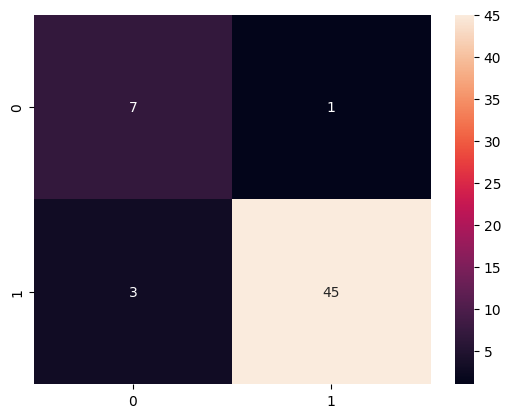

In [122]:
sns.heatmap(cm,annot=True,fmt='d')